In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.formula.api as smf

In [3]:
df = pd.read_csv('Full_Dataset_Cycling.csv')

In [4]:
df.isnull().sum()

Site_ID             0
Direction           0
Modus               0
Start_Time          0
End_Time            0
Count         1085221
dtype: int64

In [5]:
df[df["Count"].isna()].head(20)

,Site_ID,Direction,Modus,Start_Time,End_Time,Count
25857,Location_Tag_5,IN,FIETSERS,2019-08-22 08:15:00.0,2019-08-22 08:30:00.0,NaN
25858,Location_Tag_5,IN,FIETSERS,2019-08-22 08:30:00.0,2019-08-22 08:45:00.0,NaN
25859,Location_Tag_5,IN,FIETSERS,2019-08-22 08:45:00.0,2019-08-22 09:00:00.0,NaN
25860,Location_Tag_5,IN,FIETSERS,2019-08-22 09:00:00.0,2019-08-22 09:15:00.0,NaN
28833,Location_Tag_5,OUT,FIETSERS,2019-08-22 08:15:00.0,2019-08-22 08:30:00.0,NaN
28834,Location_Tag_5,OUT,FIETSERS,2019-08-22 08:30:00.0,2019-08-22 08:45:00.0,NaN
28835,Location_Tag_5,OUT,FIETSERS,2019-08-22 08:45:00.0,2019-08-22 09:00:00.0,NaN
28836,Location_Tag_5,OUT,FIETSERS,2019-08-22 09:00:00.0,2019-08-22 09:15:00.0,NaN
119040,Location_Tag_21,IN,FIETSERS,2019-08-26 03:00:00.0,2019-08-26 03:15:00.0,NaN
119041,Location_Tag_21,IN,FIETSERS,2019-08-26 03:15:00.0,2019-08-26 03:30:00.0,NaN


In [6]:
df[df["Count"].isna()]["Site_ID"].nunique()

150

In [7]:
df["Start_Time"] = pd.to_datetime(df["Start_Time"])
df["End_Time"] = pd.to_datetime(df["End_Time"])
df["site_direction"] = df["Site_ID"] + "_" + df["Direction"]

In [13]:
df_daily = df.dropna(subset=["Count"]).set_index("Start_Time").groupby("Site_ID").resample("D").agg({"Count": "sum"}).reset_index()


In [14]:
df_daily["Count"].isna().sum()

np.int64(0)

In [15]:
def add_time_features(data):
    data = data.copy()
    
    data["dayofweek"] = data["Start_Time"].dt.dayofweek
    data["month"] = data["Start_Time"].dt.month
    data["dayofyear"] = data["Start_Time"].dt.dayofyear
    data["is_weekend"] = (data["dayofweek"] >= 5).astype(int)
    
    # yearly seasonality
    data["month_sin"] = np.sin(2 * np.pi * data["month"] / 12)
    data["month_cos"] = np.cos(2 * np.pi * data["month"] / 12)
    data["doy_sin"] = np.sin(2 * np.pi * data["dayofyear"] / 365)
    data["doy_cos"] = np.cos(2 * np.pi * data["dayofyear"] / 365)
    
    return data

In [16]:
df_daily = add_time_features(df_daily)

In [17]:
df_daily = df_daily.sort_values(["Site_ID", "Start_Time"])

df_daily["lag_1"] = df_daily.groupby("Site_ID")["Count"].shift(1)
df_daily["lag_7"] = df_daily.groupby("Site_ID")["Count"].shift(7)
df_daily["lag_14"] = df_daily.groupby("Site_ID")["Count"].shift(14)
df_daily["lag_28"] = df_daily.groupby("Site_ID")["Count"].shift(28)


df_model = df_daily.dropna().copy()

In [18]:
df_model.head()

,Site_ID,Start_Time,Count,dayofweek,month,dayofyear,is_weekend,month_sin,month_cos,doy_sin,doy_cos,lag_1,lag_7,lag_14,lag_28
28,Location_Tag_1,2019-08-29,499.0,3,8,241,0,-0.866025,-5.000000e-01,-0.845249,-0.534373,472.0,501.0,237.0,495.0
29,Location_Tag_1,2019-08-30,483.0,4,8,242,0,-0.866025,-5.000000e-01,-0.854322,-0.519744,499.0,431.0,291.0,364.0
30,Location_Tag_1,2019-08-31,292.0,5,8,243,1,-0.866025,-5.000000e-01,-0.863142,-0.504961,483.0,263.0,96.0,273.0
31,Location_Tag_1,2019-09-01,818.0,6,9,244,1,-1.000000,-1.836970e-16,-0.871706,-0.490029,292.0,382.0,151.0,424.0
32,Location_Tag_1,2019-09-02,537.0,0,9,245,0,-1.000000,-1.836970e-16,-0.880012,-0.474951,818.0,546.0,363.0,455.0


設定: 2026-05-16時点で、2026-05-17〜2026-11-16を予測  <br>
<br>
cutoff = 2025-05-16<br>
test = 2025-05-17〜2025-11-16<br>
train = cutoff以前の2年分<br>
<br>
train: 2023-05-17〜2025-05-16<br>
test : 2025-05-17〜2025-11-16

In [19]:
def split_train_test(cutoff="2025-05-16",forecast_end="2025-11-16",years=2,df_daily=df_daily):
    cutoff = pd.Timestamp(cutoff)
    forecast_end = pd.Timestamp(forecast_end)

    train_start = cutoff - pd.DateOffset(years=years)

    train_eval = df_daily[
        (df_daily["Start_Time"] >= train_start) &
        (df_daily["Start_Time"] <= cutoff)
    ].copy()

    test_eval_actual = df_daily[
        (df_daily["Start_Time"] > cutoff) &
        (df_daily["Start_Time"] <= forecast_end)
    ].copy()

    train_eval = train_eval.sort_values(["Site_ID", "Start_Time"])

    train_eval["lag_1"] = train_eval.groupby("Site_ID")["Count"].shift(1)
    train_eval["lag_7"] = train_eval.groupby("Site_ID")["Count"].shift(7)

    train_eval = train_eval.dropna().copy()

    return train_eval, test_eval_actual

## let's start with 2Y data

In [ ]:
cutoff_2Y = pd.Timestamp("2025-05-16")
forecast_end_2Y = pd.Timestamp("2025-11-16")

train_start_2Y = cutoff_2Y - pd.DateOffset(years=2)

train_eval_2Y = df_daily[
    (df_daily["Start_Time"] >= train_start_2Y) &
    (df_daily["Start_Time"] <= cutoff_2Y)
].copy()

test_eval_actual_2Y = df_daily[
    (df_daily["Start_Time"] > cutoff_2Y) &
    (df_daily["Start_Time"] <= forecast_end_2Y)
].copy()

In [24]:
test_eval_actual_2Y['Count'].describe()

count    25905.000000
mean       605.371241
std        791.317010
min          0.000000
25%        189.000000
50%        386.000000
75%        705.000000
max      11465.000000
Name: Count, dtype: float64

In [25]:
train_eval_2Y = train_eval_2Y.sort_values(["Site_ID", "Start_Time"])

train_eval_2Y["lag_1"] = train_eval_2Y.groupby("Site_ID")["Count"].shift(1)
train_eval_2Y["lag_7"] = train_eval_2Y.groupby("Site_ID")["Count"].shift(7)

train_eval_2Y = train_eval_2Y.dropna().copy()

In [26]:
formula = """
Count ~ lag_1 + lag_7
      + month_sin + month_cos
      + C(dayofweek)
      + C(Site_ID)
"""

fem_daily_2Y = smf.ols(formula, data=train_eval_2Y).fit()

In [27]:
print(fem_daily_2Y.summary())

                            OLS Regression Results                            
Dep. Variable:                  Count   R-squared:                       0.857
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     4022.
Date:                Sat, 16 May 2026   Prob (F-statistic):               0.00
Time:                        23:30:40   Log-Likelihood:            -7.1381e+05
No. Observations:              101159   AIC:                         1.428e+06
Df Residuals:                  101008   BIC:                         1.429e+06
Df Model:                         150                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

In [32]:
def recursive_forecast_daily_fem(model, history, future_dates):
    history = history.copy()
    predictions = []

    sites = history["Site_ID"].unique()

    for date in future_dates:
        future_rows = pd.DataFrame({
            "Site_ID": sites,
            "Start_Time": date
        })

        future_rows = add_time_features(future_rows)

        lag_1 = (
            history[history["Start_Time"] == date - pd.Timedelta(days=1)]
            [["Site_ID", "Count"]]
            .rename(columns={"Count": "lag_1"})
        )

        lag_7 = (
            history[history["Start_Time"] == date - pd.Timedelta(days=7)]
            [["Site_ID", "Count"]]
            .rename(columns={"Count": "lag_7"})
        )

        lag_14 = (
            history[history["Start_Time"] == date - pd.Timedelta(days=14)]
            [["Site_ID", "Count"]]
            .rename(columns={"Count": "lag_14"})
        )

        lag_28 = (
            history[history["Start_Time"] == date - pd.Timedelta(days=28)]
            [["Site_ID", "Count"]]
            .rename(columns={"Count": "lag_28"})
        )

        future_rows = future_rows.merge(lag_1, on="Site_ID", how="left")
        future_rows = future_rows.merge(lag_7, on="Site_ID", how="left")
        future_rows = future_rows.merge(lag_14, on="Site_ID", how="left")
        future_rows = future_rows.merge(lag_28, on="Site_ID", how="left")

        # lagが作れないsiteは除く
        future_rows = future_rows.dropna(subset=["lag_1", "lag_7", "lag_14", "lag_28"]).copy()

        future_rows["pred"] = model.predict(future_rows)

        # Countとしてhistoryに追加して、次の日以降のlagに使う
        append_rows = future_rows[["Site_ID", "Start_Time", "pred"]].rename(
            columns={"pred": "Count"}
        )

        history = pd.concat([history, append_rows], ignore_index=True)
        predictions.append(future_rows)

    return pd.concat(predictions, ignore_index=True)

In [33]:
def asses_results(fem_daily,train_eval,test_eval_actual,cutoff="2025-05-16",forecast_end="2025-11-16"):
    future_dates = pd.date_range(
        start=pd.Timestamp(cutoff) + pd.Timedelta(days=1),
        end=pd.Timestamp(forecast_end),
        freq="D"
    )

    pred_eval = recursive_forecast_daily_fem(
        model=fem_daily,
        history=train_eval[["Site_ID", "Start_Time", "Count"]].copy(),
        future_dates=future_dates
    )

    eval_df = pred_eval.merge(
        test_eval_actual[["Site_ID", "Start_Time", "Count"]],
        on=["Site_ID", "Start_Time"],
        how="inner"
    )

    eval_df = eval_df.rename(columns={"Count": "actual"})

    mae = mean_absolute_error(eval_df["actual"], eval_df["pred"])
    rmse = np.sqrt(mean_squared_error(eval_df["actual"], eval_df["pred"]))

    print("Recursive FEM MAE:", mae)
    print("Recursive FEM RMSE:", rmse)

    return eval_df

In [29]:
future_dates_2Y = pd.date_range(
    start=cutoff_2Y + pd.Timedelta(days=1),
    end=forecast_end_2Y,
    freq="D"
)

pred_eval_2Y = recursive_forecast_daily_fem(
    model=fem_daily_2Y,
    history=train_eval_2Y[["Site_ID", "Start_Time", "Count"]].copy(),
    future_dates=future_dates_2Y
)

In [30]:
eval_df_2Y = pred_eval_2Y.merge(
    test_eval_actual_2Y[["Site_ID", "Start_Time", "Count"]],
    on=["Site_ID", "Start_Time"],
    how="inner"
)

eval_df_2Y = eval_df_2Y.rename(columns={"Count": "actual"})

In [31]:
mae_2Y = mean_absolute_error(eval_df_2Y["actual"], eval_df_2Y["pred"])
rmse_2Y = np.sqrt(mean_squared_error(eval_df_2Y["actual"], eval_df_2Y["pred"]))

print("Recursive FEM MAE:", mae_2Y)
print("Recursive FEM RMSE:", rmse_2Y)

Recursive FEM MAE: 231.61577767094388
Recursive FEM RMSE: 492.72597281970974


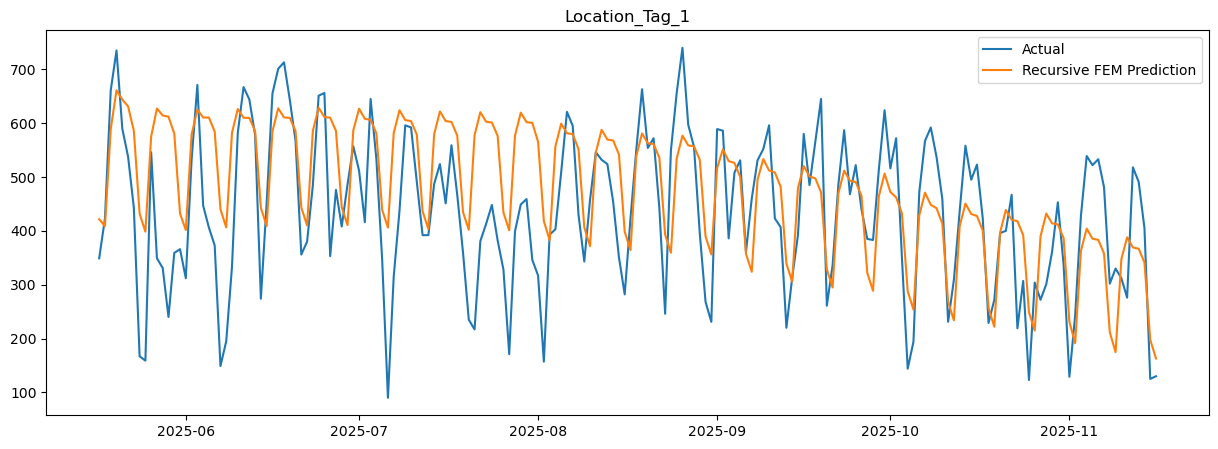

In [32]:
example_site = eval_df_2Y["Site_ID"].iloc[0]

plot_df = eval_df_2Y[
    eval_df_2Y["Site_ID"] == example_site
].copy()

plt.figure(figsize=(15,5))

plt.plot(
    plot_df["Start_Time"],
    plot_df["actual"],
    label="Actual"
)

plt.plot(
    plot_df["Start_Time"],
    plot_df["pred"],
    label="Recursive FEM Prediction"
)

plt.title(example_site)
plt.legend()
plt.show()

## Now, 3Y data

In [22]:
train_eval_3Y, test_eval_actual_3Y = split_train_test(years=3)

In [24]:
train_eval_3Y.head()

,Site_ID,Start_Time,Count,dayofweek,month,dayofyear,is_weekend,month_sin,month_cos,doy_sin,doy_cos,lag_1,lag_7,lag_14,lag_28
1026,Location_Tag_1,2022-05-23,342.0,0,5,143,0,0.5,-0.866025,0.628763,-0.777597,559.0,582.0,639.0,363.0
1027,Location_Tag_1,2022-05-24,356.0,1,5,144,0,0.5,-0.866025,0.615285,-0.788305,342.0,639.0,647.0,474.0
1028,Location_Tag_1,2022-05-25,428.0,2,5,145,0,0.5,-0.866025,0.601624,-0.798779,356.0,729.0,701.0,620.0
1029,Location_Tag_1,2022-05-26,322.0,3,5,146,0,0.5,-0.866025,0.587785,-0.809017,428.0,365.0,601.0,651.0
1030,Location_Tag_1,2022-05-27,294.0,4,5,147,0,0.5,-0.866025,0.573772,-0.819015,322.0,260.0,532.0,461.0


In [25]:
formula = """
Count ~ lag_1 + lag_7 + lag_14 + lag_28
      + doy_sin + doy_cos
      + C(dayofweek)
      + C(Site_ID)
"""

fem_daily_3Y = smf.ols(formula, data=train_eval_3Y).fit()

In [26]:
print(fem_daily_3Y.summary())

                            OLS Regression Results                            
Dep. Variable:                  Count   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.872
Method:                 Least Squares   F-statistic:                     6342.
Date:                Sun, 17 May 2026   Prob (F-statistic):               0.00
Time:                        00:23:30   Log-Likelihood:            -9.7443e+05
No. Observations:              140958   AIC:                         1.949e+06
Df Residuals:                  140805   BIC:                         1.951e+06
Df Model:                         152                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

In [34]:
eval_df_3Y = asses_results(fem_daily_3Y,train_eval_3Y,test_eval_actual_3Y)

Recursive FEM MAE: 226.1477347398067
Recursive FEM RMSE: 495.3573981280965


In [35]:
test_eval_actual_3Y["Count"].describe()

count    25905.000000
mean       605.371241
std        791.317010
min          0.000000
25%        189.000000
50%        386.000000
75%        705.000000
max      11465.000000
Name: Count, dtype: float64

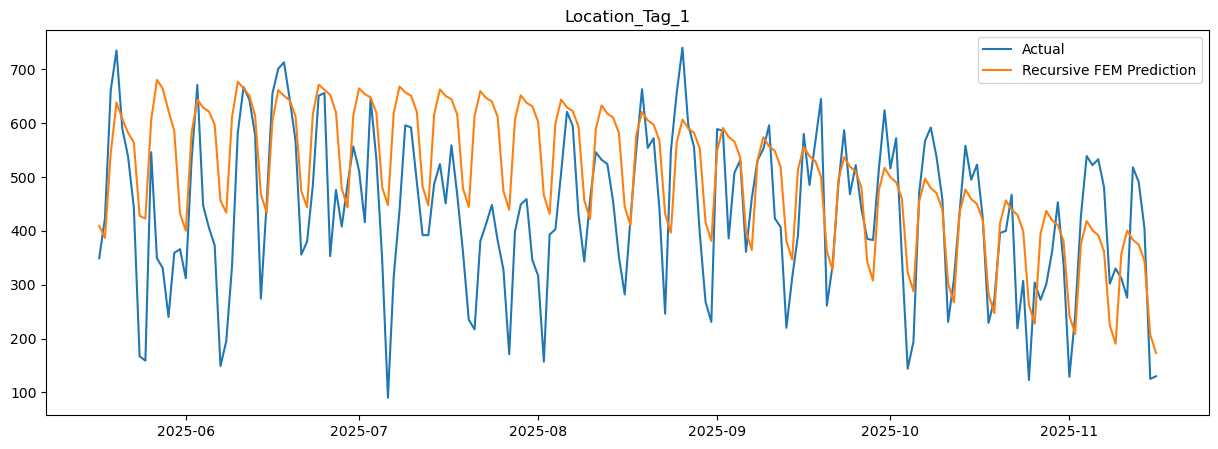

In [36]:
example_site = eval_df_3Y["Site_ID"].iloc[0]

plot_df = eval_df_3Y[
    eval_df_3Y["Site_ID"] == example_site
].copy()

plt.figure(figsize=(15,5))

plt.plot(
    plot_df["Start_Time"],
    plot_df["actual"],
    label="Actual"
)

plt.plot(
    plot_df["Start_Time"],
    plot_df["pred"],
    label="Recursive FEM Prediction"
)

plt.title(example_site)
plt.legend()
plt.show()

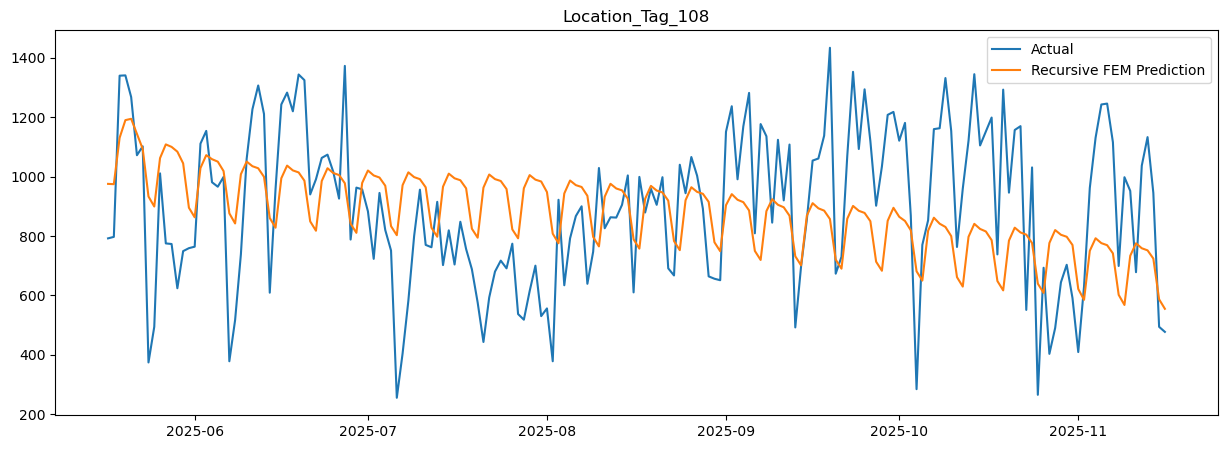

In [46]:
example_site = eval_df_3Y["Site_ID"].iloc[10]

plot_df = eval_df_3Y[
    eval_df_3Y["Site_ID"] == example_site
].copy()

plt.figure(figsize=(15,5))

plt.plot(
    plot_df["Start_Time"],
    plot_df["actual"],
    label="Actual"
)

plt.plot(
    plot_df["Start_Time"],
    plot_df["pred"],
    label="Recursive FEM Prediction"
)

plt.title(example_site)
plt.legend()
plt.show()

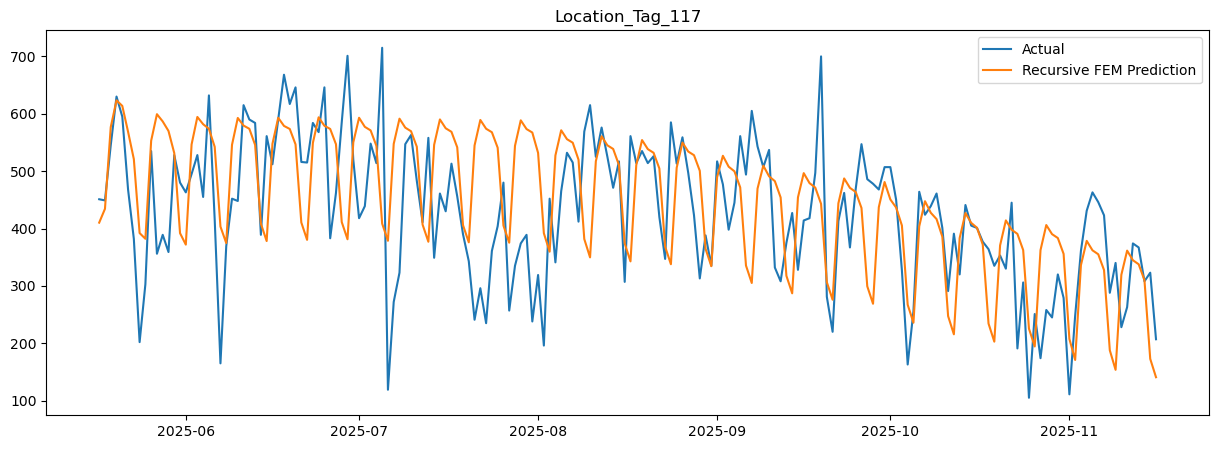

In [47]:
example_site = eval_df_3Y["Site_ID"].iloc[20]

plot_df = eval_df_3Y[
    eval_df_3Y["Site_ID"] == example_site
].copy()

plt.figure(figsize=(15,5))

plt.plot(
    plot_df["Start_Time"],
    plot_df["actual"],
    label="Actual"
)

plt.plot(
    plot_df["Start_Time"],
    plot_df["pred"],
    label="Recursive FEM Prediction"
)

plt.title(example_site)
plt.legend()
plt.show()